# 08 — Integration EDA

Joins INMET weather, INPE fire hotspot, and SISAM air quality datasets
on date + city to test relationships between climate conditions,
fire activity, and air quality across 5 Brazilian cities (2022–2024).

Note: SISAM data only covers 2022–2024. Integration analysis is limited
to this period even though INMET and hotspot data extend to 2025.

Inputs:
- data/processed/inmet_clean.parquet
- data/processed/hotspots_clean.parquet  
- data/processed/sisam_clean.parquet

Output: data/processed/integrated.parquet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve()
PROCESSED = ROOT / "data" / "processed"

# Load all three datasets
df_weather = pd.read_parquet(PROCESSED / "inmet_clean.parquet")
df_hotspots = pd.read_parquet(PROCESSED / "hotspots_clean.parquet")
df_sisam = pd.read_parquet(PROCESSED / "sisam_clean.parquet")

# City colors — consistent across all notebooks
city_colors = {
    "Manaus": "#e05c2a",
    "Brasília": "#e0a82a",
    "Belo Horizonte": "#4a9e6b",
    "São Paulo": "#4a7ab5",
    "Porto Alegre": "#7b5ea7",
}

print("INMET shape:", df_weather.shape)
print("Hotspots shape:", df_hotspots.shape)
print("SISAM shape:", df_sisam.shape)

INMET shape: (266592, 25)
Hotspots shape: (3864, 11)
SISAM shape: (5480, 9)


In [2]:
# Check row counts per city per day/night split
# UTC offsets per city
utc_offsets = {
    "Belo Horizonte": -3,
    "Brasília": -3,
    "Porto Alegre": -3,
    "São Paulo": -3,
    "Manaus": -4,
}

# Add local hour to INMET data
df_weather["local_hour"] = (
    df_weather["timestamp"].dt.hour +
    df_weather["city"].map(utc_offsets)
) % 24

# Define daytime as 06:00–18:00 local time
df_weather["is_daytime"] = df_weather["local_hour"].between(6, 18)

print("Total INMET rows:", len(df_weather))
print("Daytime rows:", df_weather["is_daytime"].sum())
print("Nighttime rows:", (~df_weather["is_daytime"]).sum())
print("\nDaytime hours per city-day (should be ~13):")
print(
    df_weather[df_weather["is_daytime"]]
    .groupby(["city", df_weather["timestamp"].dt.date])
    .size()
    .groupby("city")
    .mean()
    .round(1)
)

Total INMET rows: 266592
Daytime rows: 144404
Nighttime rows: 122188

Daytime hours per city-day (should be ~13):
city
Belo Horizonte    27.1
Brasília          13.0
Manaus            13.0
Porto Alegre      19.7
São Paulo         26.0
dtype: float64


In [4]:
# Check how many stations per city contribute to each hour
print(
    df_weather.groupby(["city", df_weather["timestamp"].dt.date, "local_hour"])
    ["estacao"].nunique()
    .groupby("city")
    .mean()
    .round(1)
)

city
Belo Horizonte    2.1
Brasília          1.0
Manaus            1.0
Porto Alegre      1.5
São Paulo         2.0
Name: estacao, dtype: float64


In [5]:
# Step 1 — aggregate from station level to city-hour level
# This collapses multiple stations into one reading per city per hour
df_city_hourly = (
    df_weather.groupby(["city", "timestamp", "local_hour", "is_daytime"])
    .agg(
        temp_c=("temp_c", "mean"),
        humidity_pct=("humidity_pct", "mean"),
        precip_mm=("precip_mm", "mean"),      # mean across stations, not sum
        wind_speed_ms=("wind_speed_ms", "mean"),
        wind_gust_ms=("wind_gust_ms", "mean"),
        pressure_mb=("pressure_mb", "mean"),
        radiation_kjm2=("radiation_kjm2", "mean"),
    )
    .reset_index()
)

print(f"Shape: {df_city_hourly.shape}")
print(f"Expected ~{266592 // 2:.0f} rows (halved by station collapse)")

# Verify hours per city-day now
print("\nHours per city-day after station collapse:")
print(
    df_city_hourly[df_city_hourly["is_daytime"]]
    .groupby(["city", df_city_hourly["timestamp"].dt.date])
    .size()
    .groupby("city")
    .mean()
    .round(1)
)

Shape: (175320, 11)
Expected ~133296 rows (halved by station collapse)

Hours per city-day after station collapse:
city
Belo Horizonte    13.0
Brasília          13.0
Manaus            13.0
Porto Alegre      13.0
São Paulo         13.0
dtype: float64


In [6]:
# Step 2 — aggregate from city-hour to city-day, split by day/night
# Daytime: capture peaks and minimums that drive air quality dynamics
# Nighttime: capture conditions that affect pollutant accumulation overnight

# Add date column for grouping
df_city_hourly["date"] = df_city_hourly["timestamp"].dt.date

# Daytime aggregation (06:00–18:00 local)
df_day = (
    df_city_hourly[df_city_hourly["is_daytime"]]
    .groupby(["city", "date"])
    .agg(
        temp_mean=("temp_c", "mean"),
        temp_max=("temp_c", "max"),         # peak heat — drives O3 formation
        temp_min=("temp_c", "min"),
        humidity_mean=("humidity_pct", "mean"),
        humidity_min=("humidity_pct", "min"),  # afternoon trough — fire risk proxy
        precip_total=("precip_mm", "sum"),
        wind_mean=("wind_speed_ms", "mean"),
        wind_max=("wind_gust_ms", "max"),    # peak gust — pollutant dispersion
        pressure_mean=("pressure_mb", "mean"),
        radiation_mean=("radiation_kjm2", "mean"),  # daytime only — meaningful
    )
    .reset_index()
)

# Nighttime aggregation (18:00–06:00 local)
df_night = (
    df_city_hourly[~df_city_hourly["is_daytime"]]
    .groupby(["city", "date"])
    .agg(
        temp_mean_night=("temp_c", "mean"),
        temp_min_night=("temp_c", "min"),   # coldest point — inversion indicator
        humidity_mean_night=("humidity_pct", "mean"),
        humidity_max_night=("humidity_pct", "max"),  # peak humidity at night
        wind_mean_night=("wind_speed_ms", "mean"),   # calm nights = accumulation
        wind_min_night=("wind_speed_ms", "min"),     # minimum wind — worst case
        pressure_mean_night=("pressure_mb", "mean"),
    )
    .reset_index()
)

# Convert date to datetime
df_day["date"] = pd.to_datetime(df_day["date"])
df_night["date"] = pd.to_datetime(df_night["date"])

print(f"Daytime daily shape: {df_day.shape}")
print(f"Nighttime daily shape: {df_night.shape}")
print(f"\nSample daytime:")
print(df_day.head(3).to_string(index=False))

Daytime daily shape: (7305, 12)
Nighttime daily shape: (7305, 9)

Sample daytime:
          city       date  temp_mean  temp_max  temp_min  humidity_mean  humidity_min  precip_total  wind_mean  wind_max  pressure_mean  radiation_mean
Belo Horizonte 2022-01-01  19.984615     21.60     18.50      88.153846          80.5          34.2   2.200000      7.95     897.730769      540.065385
Belo Horizonte 2022-01-02  21.969231     25.85     18.05      79.615385          65.5           2.8   2.307692     10.10     898.515385     1168.396154
Belo Horizonte 2022-01-03  21.665385     24.05     18.75      82.615385          69.0           9.7   1.953846      6.25     898.242308      966.723077


In [7]:
# Step 3 — join all three datasets on date + city
# Left join from SISAM (air quality) as the anchor — it has every day covered
# Hotspots joined with fill_value=0 — absence of fire is genuinely zero, not unknown

# Limit to 2022–2024 to match SISAM coverage
df_sisam_copy = df_sisam.copy()
df_sisam_copy["date"] = pd.to_datetime(df_sisam_copy["date"])

# Join daytime weather onto SISAM
df_integrated = df_sisam_copy.merge(
    df_day,
    on=["city", "date"],
    how="left",
)

# Join nighttime weather
df_integrated = df_integrated.merge(
    df_night,
    on=["city", "date"],
    how="left",
)

# Join hotspots — fill missing days with 0 (no fires = zero activity)
df_hotspots_copy = df_hotspots[["city", "date", "hotspot_count", "frp_total",
                                  "frp_mean", "risk_fire_mean", "days_no_rain_mean",
                                  "precip_mean", "biome_primary"]].copy()
df_hotspots_copy["date"] = pd.to_datetime(df_hotspots_copy["date"])

df_integrated = df_integrated.merge(
    df_hotspots_copy,
    on=["city", "date"],
    how="left",
)

# Fill zero-hotspot days — absence of fire is a real zero, not missing data
fire_cols = ["hotspot_count", "frp_total", "frp_mean", "risk_fire_mean",
             "days_no_rain_mean", "precip_mean"]
df_integrated[fire_cols] = df_integrated[fire_cols].fillna(0)

# biome_primary is categorical — fill with "None" for non-fire days
df_integrated["biome_primary"] = df_integrated["biome_primary"].fillna("None")

# Add year column
df_integrated["year"] = df_integrated["date"].dt.year

print(f"Shape: {df_integrated.shape}")
print(f"Date range: {df_integrated['date'].min()} → {df_integrated['date'].max()}")
print(f"Cities: {sorted(df_integrated['city'].unique())}")
print(f"\nNulls:")
print(df_integrated.isnull().sum()[df_integrated.isnull().sum() > 0])

Shape: (5480, 33)
Date range: 2022-01-01 00:00:00 → 2024-12-31 00:00:00
Cities: ['Belo Horizonte', 'Brasília', 'Manaus', 'Porto Alegre', 'São Paulo']

Nulls:
Series([], dtype: int64)


In [8]:
# Save integrated dataset to processed/
output_path = PROCESSED / "integrated.parquet"
df_integrated.to_parquet(output_path, index=False)

print(f"Saved to {output_path}")
print(f"Shape: {df_integrated.shape}")
print(f"File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"\nColumns:")
for col in df_integrated.columns:
    print(f"  {col:<25} {str(df_integrated[col].dtype)}")

Saved to D:\projects\air_quality_brazil\data\processed\integrated.parquet
Shape: (5480, 33)
File size: 0.44 MB

Columns:
  timestamp                 datetime64[us, UTC]
  date                      datetime64[us]
  city                      str
  year                      int32
  pm25_ugm3                 float64
  pm10_ugm3                 float64
  o3_ugm3                   float64
  co_mgm3                   float64
  no2_ugm3                  float64
  temp_mean                 float64
  temp_max                  float64
  temp_min                  float64
  humidity_mean             float64
  humidity_min              float64
  precip_total              float64
  wind_mean                 float64
  wind_max                  float64
  pressure_mean             float64
  radiation_mean            float64
  temp_mean_night           float64
  temp_min_night            float64
  humidity_mean_night       float64
  humidity_max_night        float64
  wind_mean_night           float64
  

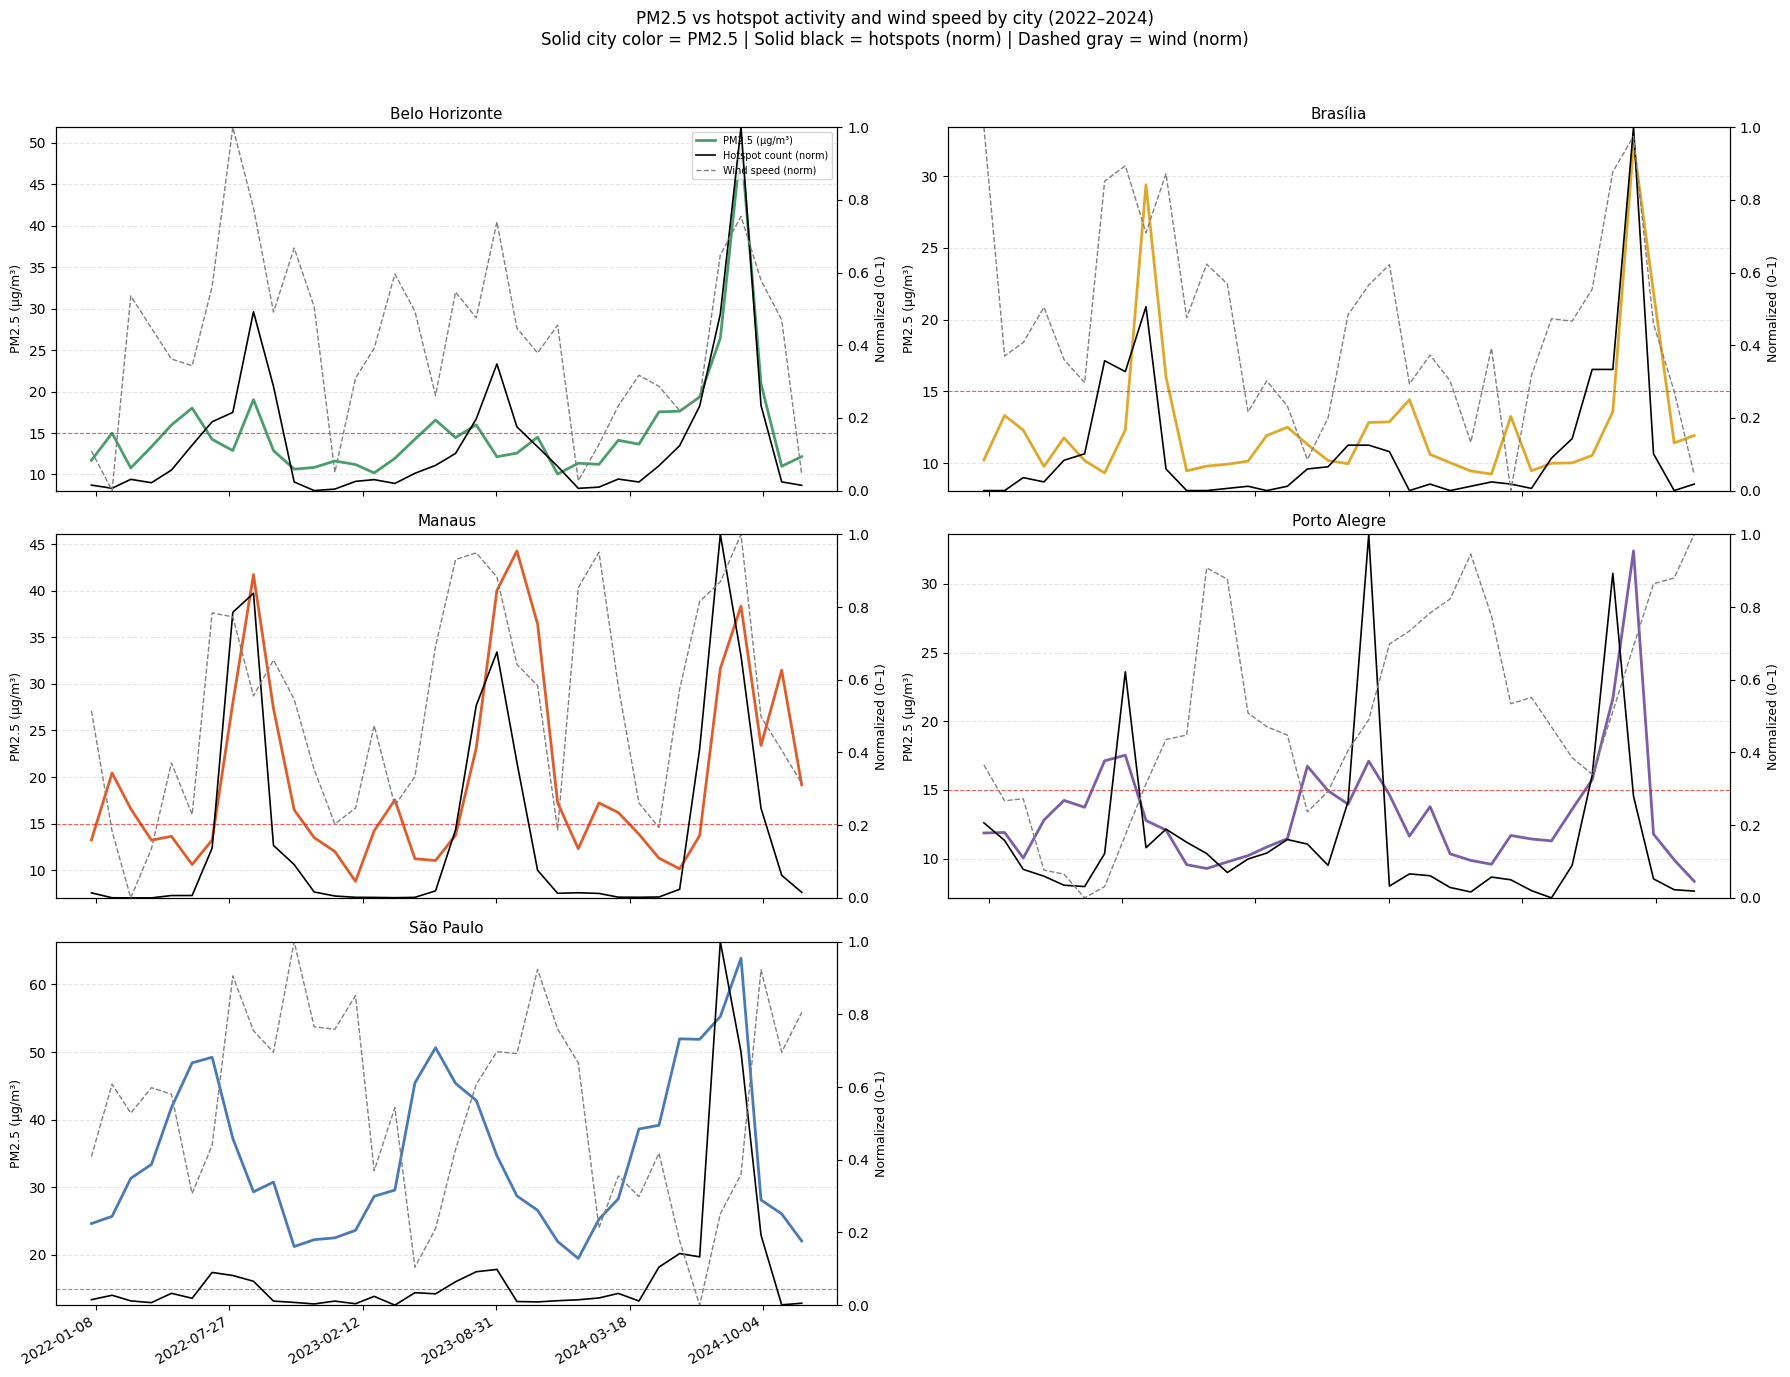

In [9]:
# Aggregate to monthly for cleaner visualization
df_integrated["year_month"] = df_integrated["date"].dt.to_period("M")

df_monthly = (
    df_integrated.groupby(["city", "year_month"])
    .agg(
        pm25_ugm3=("pm25_ugm3", "mean"),
        hotspot_count=("hotspot_count", "sum"),
        wind_mean=("wind_mean", "mean"),
        wind_max=("wind_max", "mean"),
    )
    .reset_index()
)

df_monthly["date"] = df_monthly["year_month"].dt.to_timestamp()

# Normalize hotspots and wind to 0-1 for overlay on PM2.5 axis
# PM2.5 keeps its real scale on the left axis
# Hotspots and wind share a normalized right axis

cities = sorted(df_integrated["city"].unique())
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 14))

for i, city in enumerate(cities):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    ax2 = ax.twinx()

    group = df_monthly[df_monthly["city"] == city].copy()

    # Normalize hotspots and wind to 0-1 for right axis
    for var in ["hotspot_count", "wind_mean"]:
        vmin = group[var].min()
        vmax = group[var].max()
        group[f"{var}_norm"] = (group[var] - vmin) / (vmax - vmin) if vmax > vmin else 0

    # PM2.5 — solid line on left axis
    ax.plot(
        group["date"],
        group["pm25_ugm3"],
        color=city_colors[city],
        linewidth=2,
        linestyle="-",
        label="PM2.5 (μg/m³)",
    )

    # WHO PM2.5 guideline
    ax.axhline(y=15, color="red", linewidth=0.8, linestyle="--", alpha=0.6)

    # Hotspot count — solid dark line on right axis
    ax2.plot(
        group["date"],
        group["hotspot_count_norm"],
        color="black",
        linewidth=1.2,
        linestyle="-",
        label="Hotspot count (norm)",
    )

    # Wind speed — dashed gray line on right axis
    ax2.plot(
        group["date"],
        group["wind_mean_norm"],
        color="gray",
        linewidth=1,
        linestyle="--",
        label="Wind speed (norm)",
    )

    ax.set_title(city, fontsize=11)
    ax.set_ylabel("PM2.5 (μg/m³)", fontsize=9)
    ax2.set_ylabel("Normalized (0–1)", fontsize=9)
    ax2.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    if i == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=7)

axes[2, 1].set_visible(False)

fig.suptitle(
    "PM2.5 vs hotspot activity and wind speed by city (2022–2024)\n"
    "Solid city color = PM2.5 | Solid black = hotspots (norm) | Dashed gray = wind (norm)",
    fontsize=12
)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finding 1 — Wind and fire activity have a conditional relationship with PM2.5

- When hotspot activity is low, high wind speeds coincide with lower PM2.5 —
  consistent with wind dispersing local pollutants away from the city
- When hotspot activity is high, high wind speeds coincide with elevated PM2.5 —
  consistent with wind transporting smoke from fire regions into the city
- This suggests wind and hotspots have an interaction effect on PM2.5:
  wind direction determines whether wind helps or hurts air quality

**City-specific patterns:**
- Manaus: strongest hotspot-PM2.5 alignment — fire smoke is the dominant
  driver of air quality, wind and hotspots move together
- BH: wind normally high and stable, PM2.5 flat — until 2024 when both
  wind and hotspots spike simultaneously, suggesting smoke transport
- Brasília: hotspot-PM2.5 alignment visible in spike years, wind peaks
  don't consistently drive PM2.5 down despite open plateau geography
- Porto Alegre: wind erratic and high year-round, hotspots near zero,
  PM2.5 barely responds — frontal weather dominates, fire signal minimal
- São Paulo: PM2.5 elevated year-round regardless of fire or wind activity —
  chronic urban emissions are the primary driver, fire is an amplifier only

**Limitation:** wind direction data unavailable — transport vs dispersion
  cannot be confirmed without it

**Modeling implication:** include wind × hotspot_count interaction term
  in the regression model to capture this conditional relationship

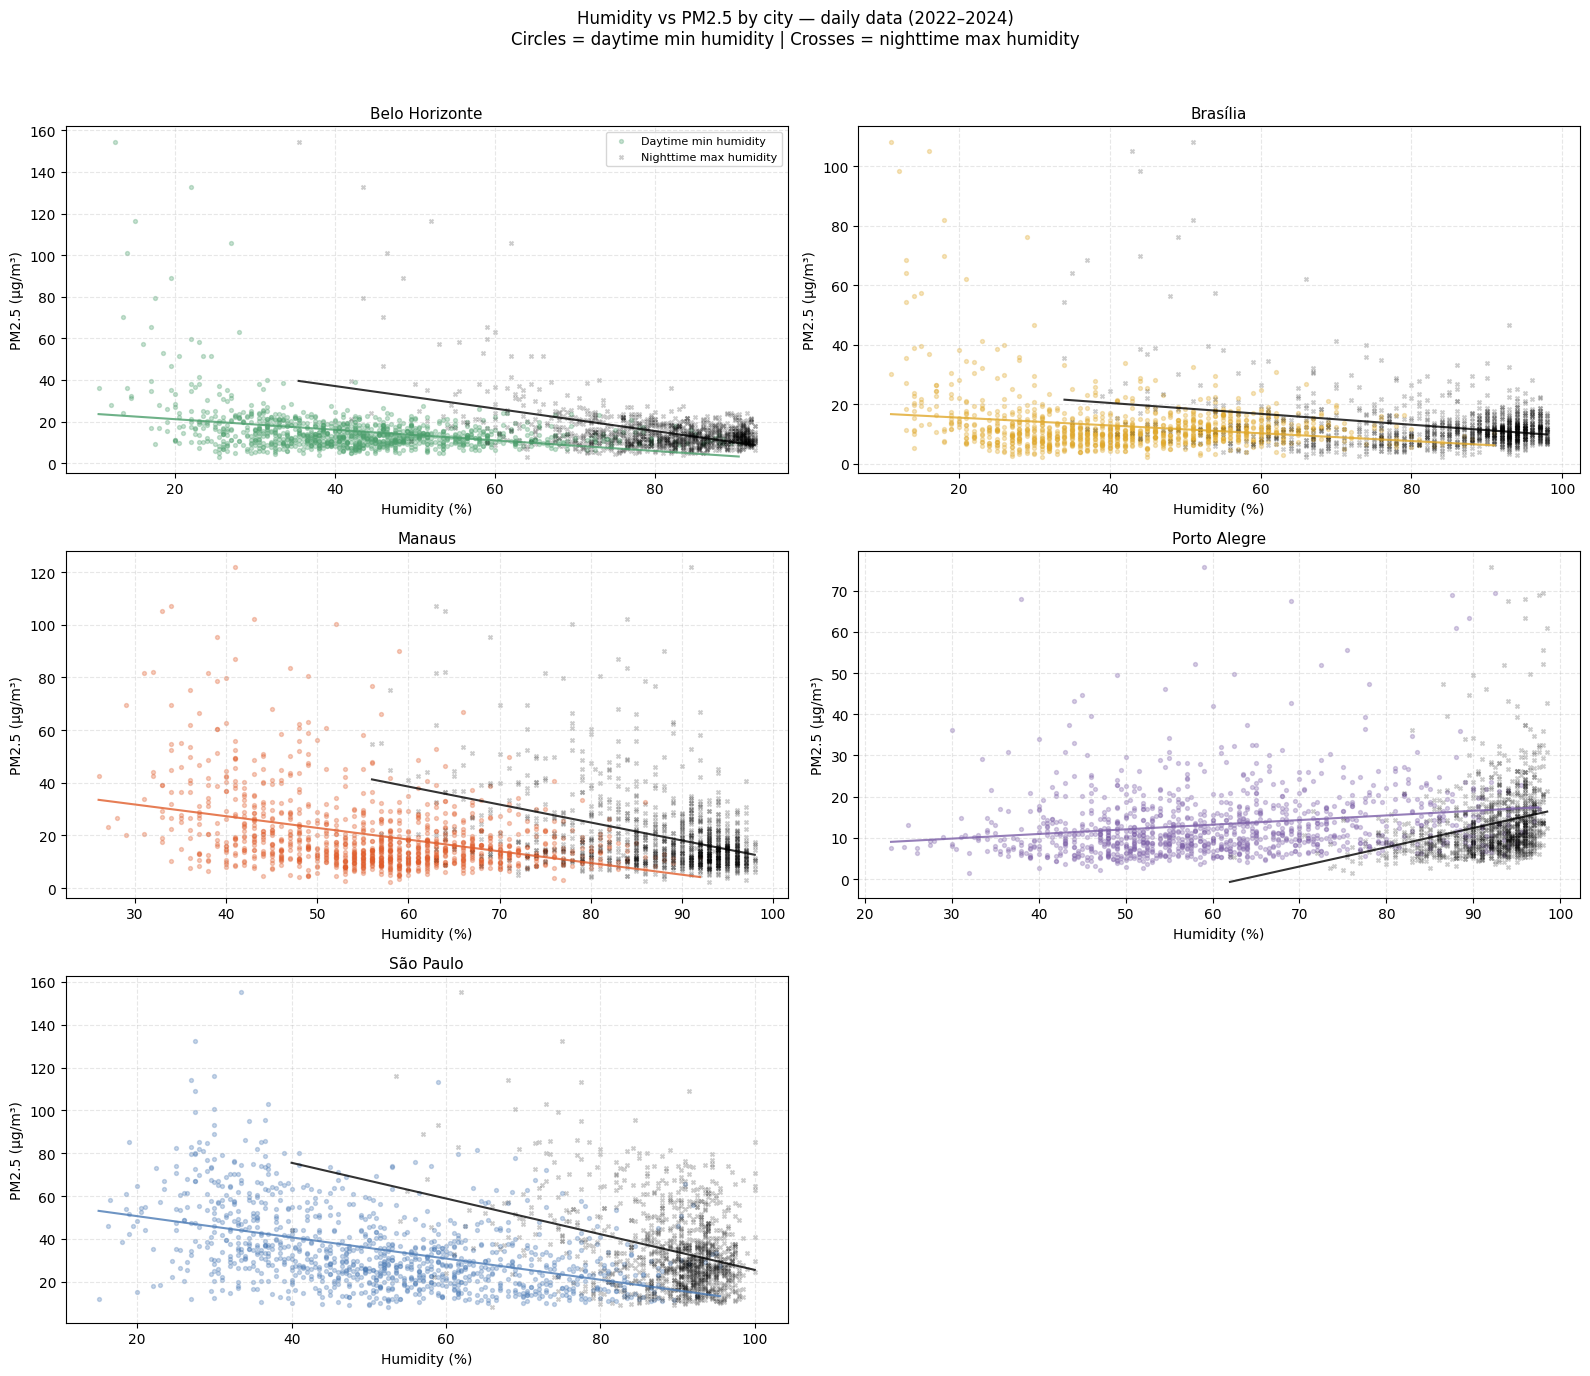

In [14]:
# ── Humidity vs PM2.5 — scatter plots and time series ────────────────────────
# Two figures:
# 1. Scatter plots — daytime min humidity and nighttime max humidity vs PM2.5
#    one subplot per city, both humidity types on the same scatter
# 2. Time series overlay — monthly PM2.5 with daytime and nighttime humidity

# ── Figure 1: Scatter plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))

for i, city in enumerate(cities):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    group = df_integrated[df_integrated["city"] == city]

    # Daytime minimum humidity vs PM2.5 — circles
    ax.scatter(
        group["humidity_min"],
        group["pm25_ugm3"],
        color=city_colors[city],
        alpha=0.3,
        s=8,
        label="Daytime min humidity",
    )

    # Nighttime maximum humidity vs PM2.5 — crosses
    ax.scatter(
        group["humidity_max_night"],
        group["pm25_ugm3"],
        color="black",
        alpha=0.2,
        s=8,
        marker="x",
        label="Nighttime max humidity",
    )

    # Add trend lines for both
    for x_col, color in [("humidity_min", city_colors[city]),
                          ("humidity_max_night", "black")]:
        x = group[x_col].dropna()
        y = group.loc[x.index, "pm25_ugm3"]
        z = pd.Series(x).corr(pd.Series(y))
        # Simple linear fit
        m, b = pd.Series(y).pipe(lambda s: (
            (s.cov(x)) / x.var(),
            s.mean() - (s.cov(x) / x.var()) * x.mean()
        ))
        x_range = pd.Series([x.min(), x.max()])
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5, alpha=0.8)

    ax.set_title(f"{city}", fontsize=11)
    ax.set_xlabel("Humidity (%)")
    ax.set_ylabel("PM2.5 (μg/m³)")
    ax.grid(linestyle="--", alpha=0.3)

    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Humidity vs PM2.5 by city — daily data (2022–2024)\n"
    "Circles = daytime min humidity | Crosses = nighttime max humidity",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

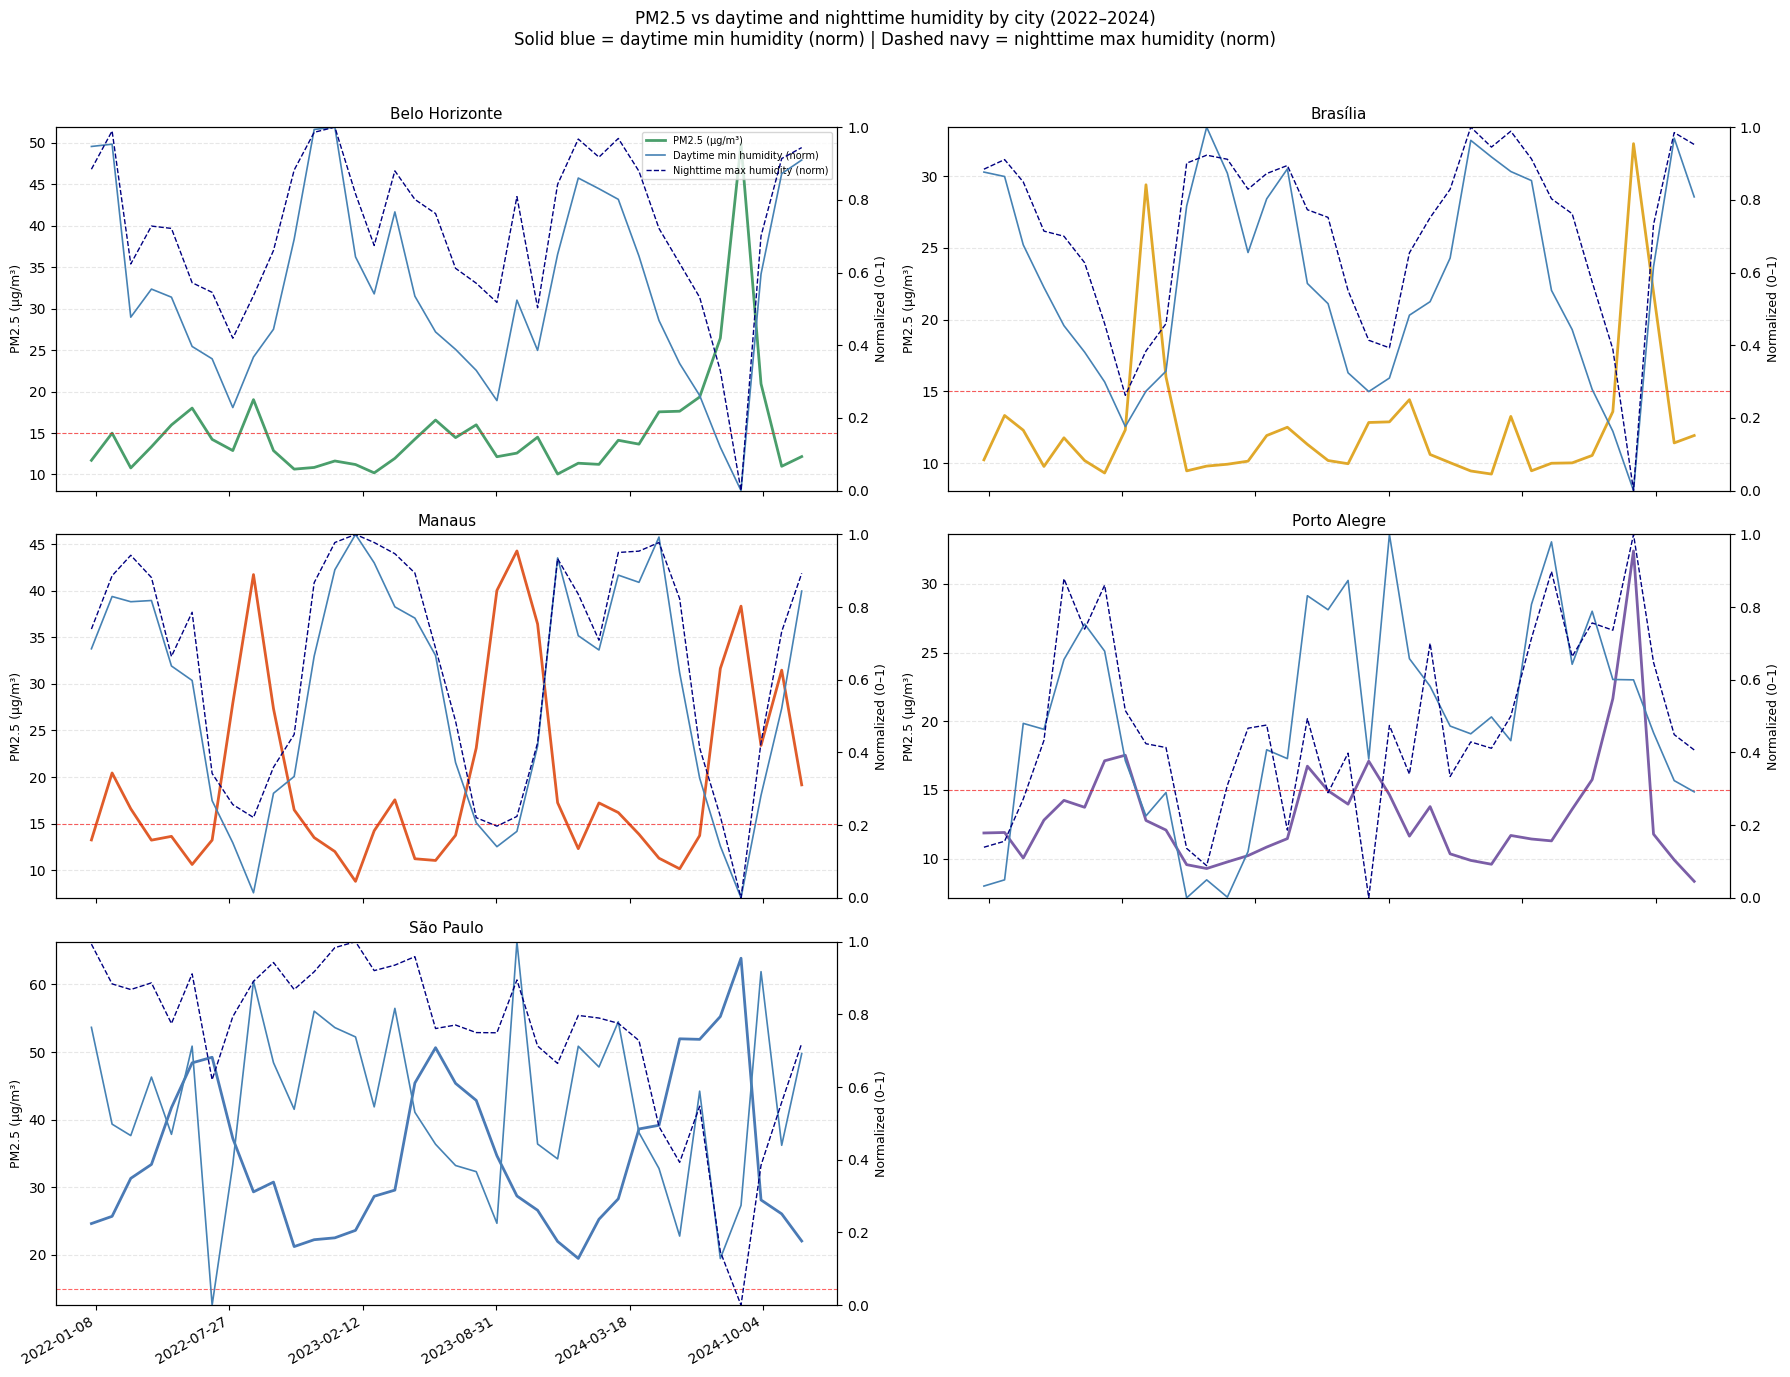

In [11]:
# ── Figure 2: Time series overlay ────────────────────────────────────────────
# Monthly PM2.5 with normalized daytime and nighttime humidity overlaid
# Normalization lets both humidity types share the right axis

df_monthly_int = (
    df_integrated.groupby(["city", "year_month"])
    .agg(
        pm25_ugm3=("pm25_ugm3", "mean"),
        humidity_min=("humidity_min", "mean"),
        humidity_max_night=("humidity_max_night", "mean"),
    )
    .reset_index()
)
df_monthly_int["date"] = df_monthly_int["year_month"].dt.to_timestamp()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 14))

for i, city in enumerate(cities):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    ax2 = ax.twinx()

    group = df_monthly_int[df_monthly_int["city"] == city].copy()

    # Normalize both humidity types to 0-1 for right axis
    for var in ["humidity_min", "humidity_max_night"]:
        vmin, vmax = group[var].min(), group[var].max()
        group[f"{var}_norm"] = (group[var] - vmin) / (vmax - vmin) if vmax > vmin else 0

    # PM2.5 — solid colored line on left axis
    ax.plot(
        group["date"],
        group["pm25_ugm3"],
        color=city_colors[city],
        linewidth=2,
        label="PM2.5 (μg/m³)",
    )
    ax.axhline(y=15, color="red", linewidth=0.8, linestyle="--", alpha=0.6)

    # Daytime min humidity — solid black on right axis
    ax2.plot(
        group["date"],
        group["humidity_min_norm"],
        color="steelblue",
        linewidth=1.2,
        linestyle="-",
        label="Daytime min humidity (norm)",
    )

    # Nighttime max humidity — dashed dark on right axis
    ax2.plot(
        group["date"],
        group["humidity_max_night_norm"],
        color="navy",
        linewidth=1,
        linestyle="--",
        label="Nighttime max humidity (norm)",
    )

    ax.set_title(city, fontsize=11)
    ax.set_ylabel("PM2.5 (μg/m³)", fontsize=9)
    ax2.set_ylabel("Normalized (0–1)", fontsize=9)
    ax2.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    if i == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  loc="upper right", fontsize=7)

axes[2, 1].set_visible(False)

fig.suptitle(
    "PM2.5 vs daytime and nighttime humidity by city (2022–2024)\n"
    "Solid blue = daytime min humidity (norm) | Dashed navy = nighttime max humidity (norm)",
    fontsize=12
)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finding 2 — Humidity inversely predicts PM2.5 but city mechanisms differ

**Brasília and Manaus — strongest and clearest inverse relationship:**
- PM2.5 rises sharply when humidity falls — scatter shows cleanest downward slope
- Mechanism is direct: drought → fire conditions → smoke → particulate pollution
- No confounding urban baseline — fire smoke is the dominant PM2.5 driver

**São Paulo — same direction but noisier:**
- Inverse humidity-PM2.5 trend visible but with much wider scatter
- Chronic urban emissions create an elevated baseline that operates independently
  of humidity — even humid days show elevated PM2.5
- Humidity explains fire-season amplification but not the year-round baseline

**Belo Horizonte — weak relationship with one exception:**
- Year-round high wind speed likely provides consistent ventilation that keeps
  PM2.5 stable regardless of humidity for most of the period
- 2024 extreme drought was severe enough to overwhelm normal wind dispersal —
  the only clear humidity-PM2.5 signal visible in BH
- Wind may be a stronger PM2.5 predictor than humidity for BH specifically

**Porto Alegre — no meaningful relationship:**
- Humidity swings driven by frontal systems unrelated to drought or fire
- PM2.5 driven by different mechanisms not captured in this dataset
- Likely requires industrial transport and frontal weather variables as predictors

**Day vs night humidity:**
- Both track closely and carry largely redundant information
- Daytime minimum humidity preferred as primary feature — represents peak
  fire risk conditions
- Multicollinearity risk if both included in the same model

**Modeling implications:**
- Humidity is a strong predictor for Brasília, Manaus, São Paulo
- BH may benefit more from wind × humidity interaction than humidity alone
- Porto Alegre likely needs a separate model or different feature set

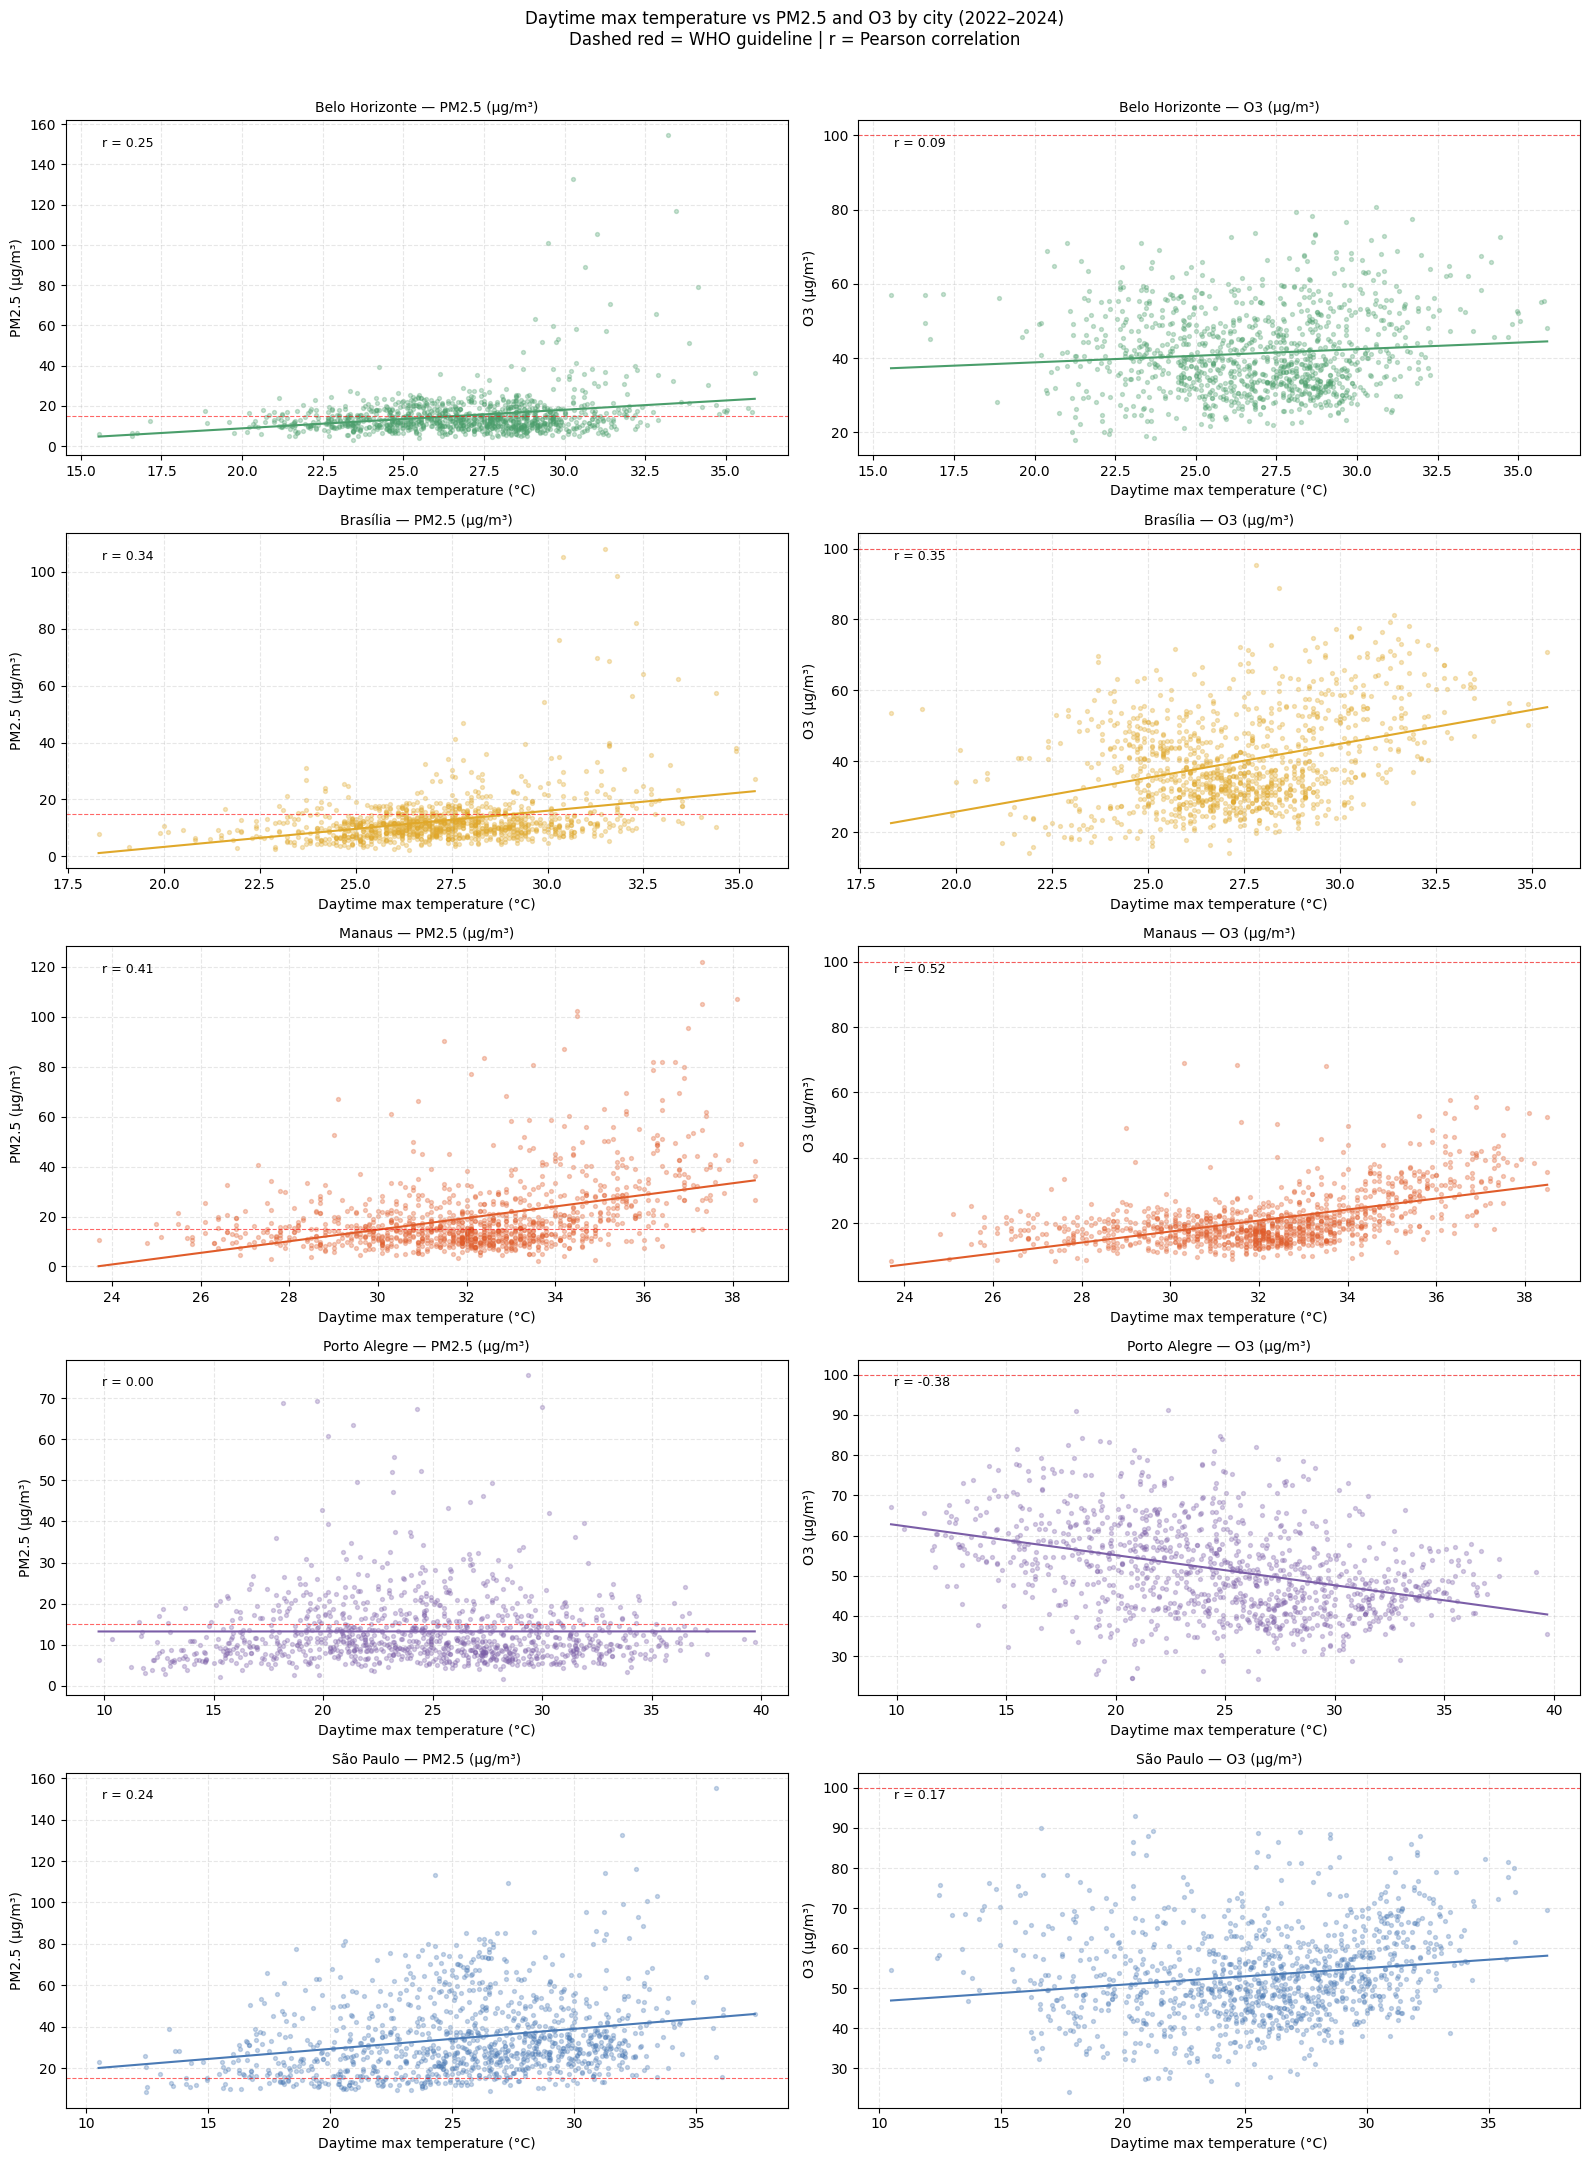

In [12]:
# ── Temperature vs PM2.5 and O3 — scatter plots ───────────────────────────────
# Two figures side by side per city:
# Left: daytime max temperature vs PM2.5
# Right: daytime max temperature vs O3
# Tests whether temperature predicts particulate vs photochemical pollution differently

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))

for i, city in enumerate(cities):
    group = df_integrated[df_integrated["city"] == city]

    for j, (y_col, y_label, who_limit) in enumerate([
        ("pm25_ugm3", "PM2.5 (μg/m³)", 15),
        ("o3_ugm3",   "O3 (μg/m³)",    100),
    ]):
        ax = axes[i, j]

        # Scatter — daytime max temperature vs pollutant
        ax.scatter(
            group["temp_max"],
            group[y_col],
            color=city_colors[city],
            alpha=0.3,
            s=8,
        )

        # Trend line
        x = group["temp_max"].dropna()
        y = group.loc[x.index, y_col]
        m = x.cov(y) / x.var()
        b = y.mean() - m * x.mean()
        x_range = pd.Series([x.min(), x.max()])
        ax.plot(x_range, m * x_range + b,
                color=city_colors[city], linewidth=1.5)

        # Correlation coefficient
        r = x.corr(y)
        ax.annotate(
            f"r = {r:.2f}",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            fontsize=9,
            color="black",
        )

        # WHO guideline
        ax.axhline(y=who_limit, color="red", linewidth=0.8,
                   linestyle="--", alpha=0.6)

        ax.set_title(f"{city} — {y_label}", fontsize=10)
        ax.set_xlabel("Daytime max temperature (°C)")
        ax.set_ylabel(y_label)
        ax.grid(linestyle="--", alpha=0.3)

fig.suptitle(
    "Daytime max temperature vs PM2.5 and O3 by city (2022–2024)\n"
    "Dashed red = WHO guideline | r = Pearson correlation",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [15]:
# Compute and print correlation table for comparison
print("Pearson r — humidity_min vs PM2.5:")
for city in cities:
    g = df_integrated[df_integrated["city"] == city]
    r = g["humidity_min"].corr(g["pm25_ugm3"])
    print(f"  {city:<20} r = {r:.2f}")

print("\nPearson r — humidity_max_night vs PM2.5:")
for city in cities:
    g = df_integrated[df_integrated["city"] == city]
    r = g["humidity_max_night"].corr(g["pm25_ugm3"])
    print(f"  {city:<20} r = {r:.2f}")

Pearson r — humidity_min vs PM2.5:
  Belo Horizonte       r = -0.33
  Brasília             r = -0.22
  Manaus               r = -0.37
  Porto Alegre         r = 0.20
  São Paulo            r = -0.44

Pearson r — humidity_max_night vs PM2.5:
  Belo Horizonte       r = -0.48
  Brasília             r = -0.28
  Manaus               r = -0.39
  Porto Alegre         r = 0.28
  São Paulo            r = -0.33


## Finding 3 — Temperature predicts PM2.5 positively but is weaker than humidity

**Correlation summary (Pearson r vs PM2.5):**

| City | humidity_min | humidity_max_night | temp_max |
|---|---|---|---|
| Belo Horizonte | -0.33 | -0.48 | 0.25 |
| Brasília | -0.22 | -0.28 | 0.34 |
| Manaus | -0.37 | -0.39 | 0.41 |
| Porto Alegre | +0.20 | +0.28 | 0.00 |
| São Paulo | -0.44 | -0.33 | 0.24 |

**Key findings:**
- Nighttime maximum humidity is the strongest single predictor for BH (-0.48)
  — consistent with temperature inversion trapping overnight pollutants
- Temperature is the strongest predictor for Brasília and Manaus — fire-driven
  cities where heat and drought are tightly coupled
- Daytime minimum humidity is strongest for SP (-0.44) — afternoon dry
  conditions amplify chronic urban emissions
- Porto Alegre shows opposite signs — humidity positively correlated with PM2.5,
  temperature uncorrelated — confirms a completely different pollution regime

**Temperature vs O3:**
- Manaus shows strongest temperature-O3 correlation (r = 0.52) — dry season
  reduces cloud cover, maximizing solar radiation and photochemical reactions
- Porto Alegre shows negative temperature-O3 correlation (r = -0.38) — cold
  fronts bring ozone-rich air from altitude, warm days have cloud cover that
  suppresses photochemical O3
- SP O3 weakly correlated with temperature (r = 0.17) despite highest NOx —
  regular rainfall scavenges precursors regardless of temperature

**Modeling implications:**
- Use nighttime max humidity for BH, daytime min humidity for SP
- Temperature and humidity are partially collinear — use both but monitor
  for multicollinearity in regression
- Porto Alegre requires separate treatment — different predictors, possibly
  a separate model

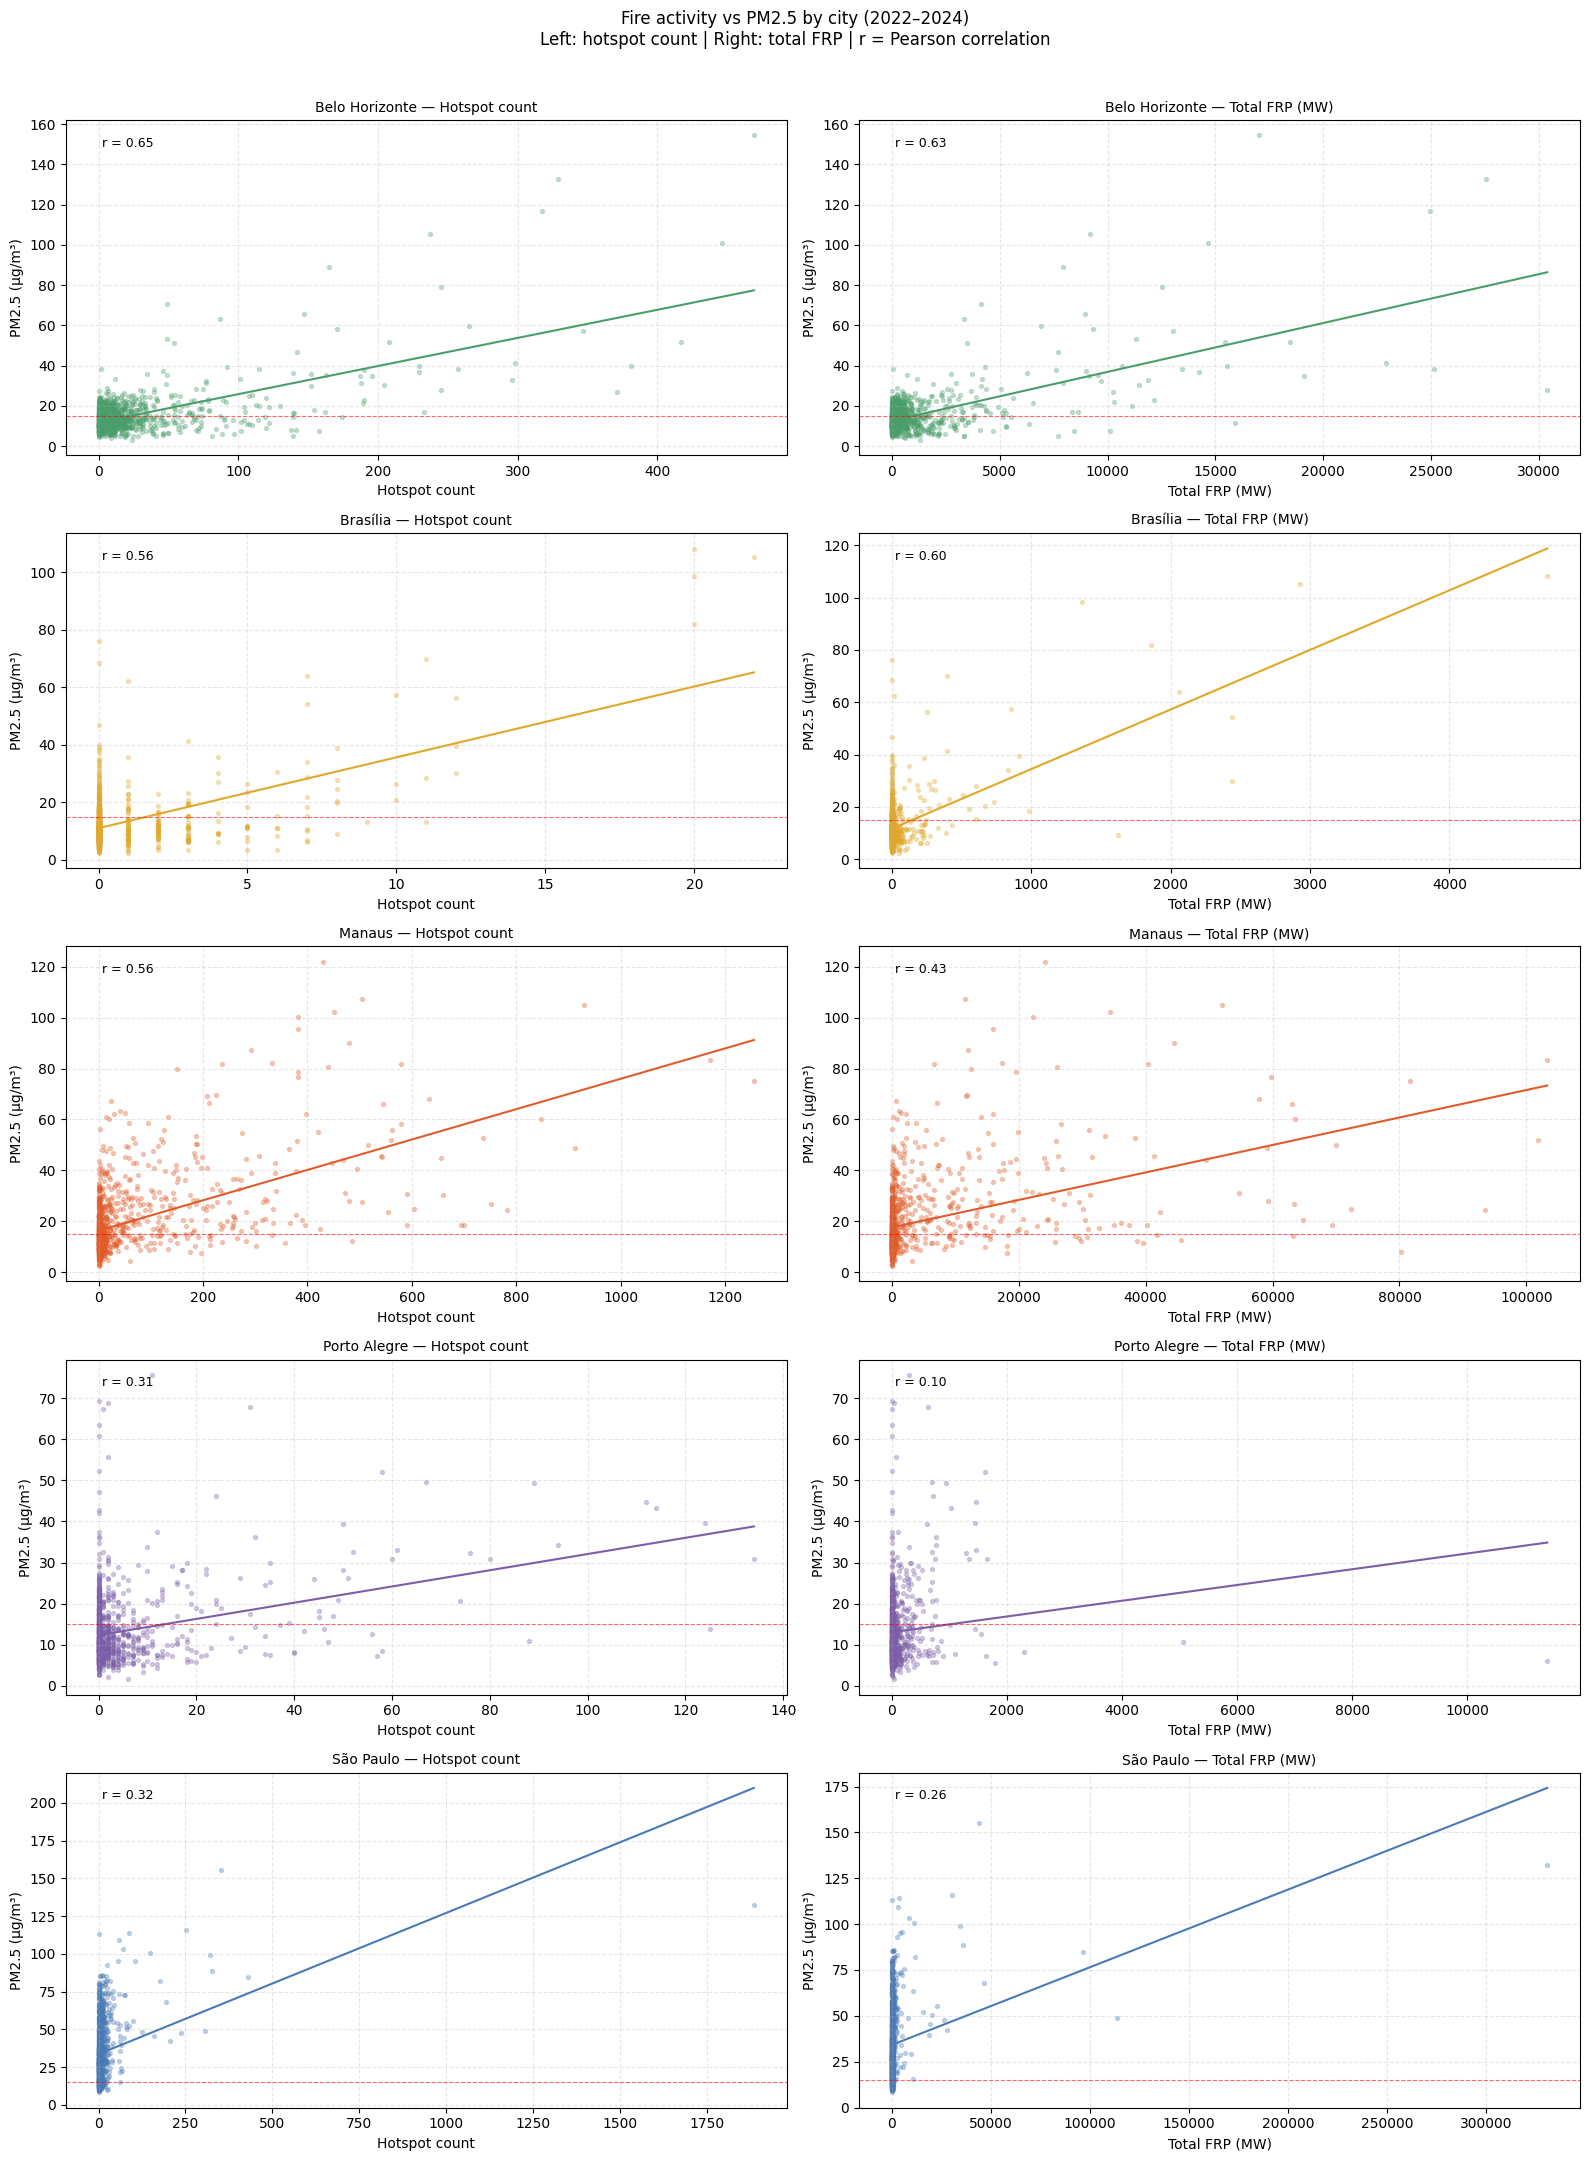

In [16]:
# ── Fire activity vs PM2.5 — hotspot count and FRP ───────────────────────────
# Tests whether fire intensity (FRP) is a stronger PM2.5 predictor than count
# Expected: FRP stronger, Manaus clearest signal

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))

for i, city in enumerate(cities):
    group = df_integrated[df_integrated["city"] == city]

    for j, (x_col, x_label) in enumerate([
        ("hotspot_count", "Hotspot count"),
        ("frp_total",     "Total FRP (MW)"),
    ]):
        ax = axes[i, j]

        ax.scatter(
            group[x_col],
            group["pm25_ugm3"],
            color=city_colors[city],
            alpha=0.3,
            s=8,
        )

        # Trend line
        x = group[x_col].dropna()
        y = group.loc[x.index, "pm25_ugm3"]
        m = x.cov(y) / x.var()
        b = y.mean() - m * x.mean()
        x_range = pd.Series([x.min(), x.max()])
        ax.plot(x_range, m * x_range + b,
                color=city_colors[city], linewidth=1.5)

        # Correlation coefficient
        r = x.corr(y)
        ax.annotate(
            f"r = {r:.2f}",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            fontsize=9,
            color="black",
        )

        # WHO guideline
        ax.axhline(y=15, color="red", linewidth=0.8,
                   linestyle="--", alpha=0.6)

        ax.set_title(f"{city} — {x_label}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel("PM2.5 (μg/m³)")
        ax.grid(linestyle="--", alpha=0.3)

fig.suptitle(
    "Fire activity vs PM2.5 by city (2022–2024)\n"
    "Left: hotspot count | Right: total FRP | r = Pearson correlation",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

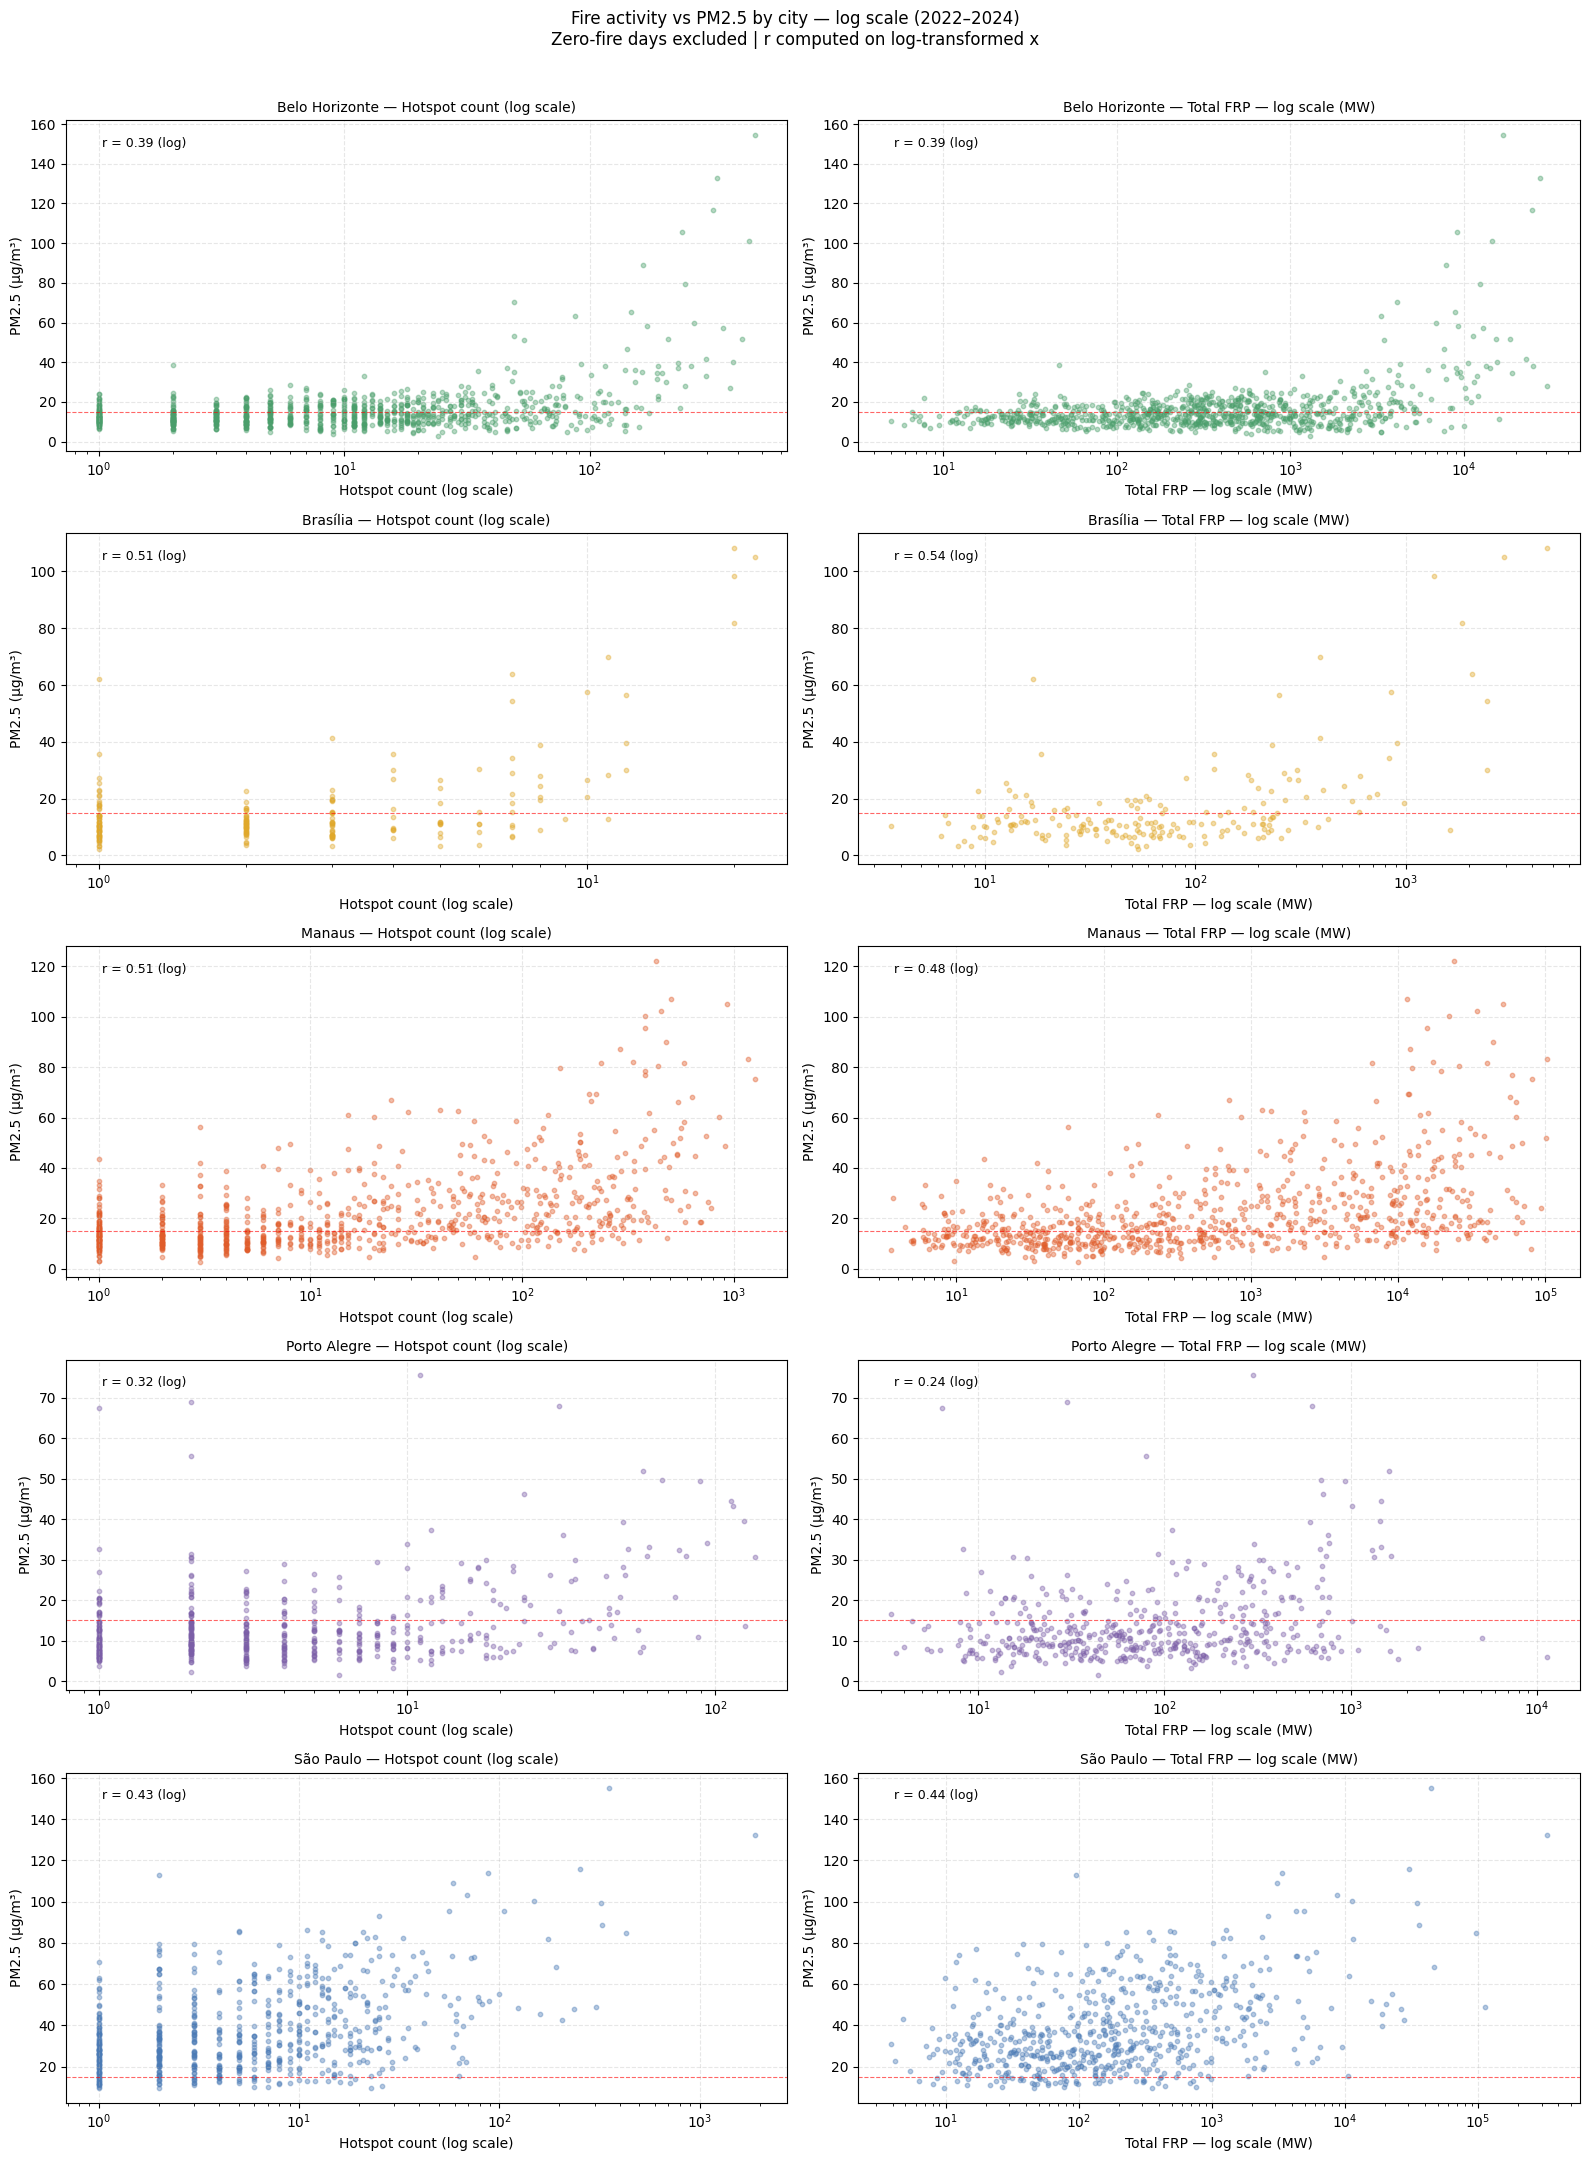

In [17]:
# Same scatter but with log scale on x-axis
# Log transformation handles right-skewed fire data

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))

for i, city in enumerate(cities):
    group = df_integrated[
        df_integrated["city"] == city
    ].copy()

    for j, (x_col, x_label) in enumerate([
        ("hotspot_count", "Hotspot count (log scale)"),
        ("frp_total",     "Total FRP — log scale (MW)"),
    ]):
        ax = axes[i, j]

        # Filter out zero values before log transform
        # log(0) is undefined — zero-fire days are excluded from this view
        mask = group[x_col] > 0
        g = group[mask]

        ax.scatter(
            g[x_col],
            g["pm25_ugm3"],
            color=city_colors[city],
            alpha=0.4,
            s=10,
        )

        # Log scale on x-axis
        ax.set_xscale("log")

        # Correlation on log-transformed x
        import numpy as np
        x_log = np.log(g[x_col])
        y = g["pm25_ugm3"]
        r = x_log.corr(y)
        ax.annotate(
            f"r = {r:.2f} (log)",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            fontsize=9,
            color="black",
        )

        # WHO guideline
        ax.axhline(y=15, color="red", linewidth=0.8,
                   linestyle="--", alpha=0.6)

        ax.set_title(f"{city} — {x_label}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel("PM2.5 (μg/m³)")
        ax.grid(linestyle="--", alpha=0.3)

fig.suptitle(
    "Fire activity vs PM2.5 by city — log scale (2022–2024)\n"
    "Zero-fire days excluded | r computed on log-transformed x",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 4 — Fire activity predicts PM2.5 with moderate strength; count and FRP equivalent on log scale

**Linear scale correlations (hotspot count vs PM2.5):**
- BH: 0.65 | Brasília: 0.56 | Manaus: 0.56 | Porto Alegre: 0.31 | SP: 0.32
- Inflated by right-skewed distribution — extreme fire days dominate the linear fit

**Log-scale correlations (more meaningful for skewed fire data):**

| City | log(hotspot count) | log(FRP total) |
|---|---|---|
| Belo Horizonte | 0.39 | 0.39 |
| Brasília | 0.51 | 0.54 |
| Manaus | 0.51 | 0.48 |
| Porto Alegre | 0.32 | 0.24 |
| São Paulo | 0.43 | 0.44 |

**Key findings:**
- FRP and hotspot count carry nearly equivalent predictive information on log scale —
  the earlier gap was a scale artifact from extreme outliers
- Brasília shows the strongest fire-PM2.5 correlation despite lowest raw counts —
  cerrado fires are geographically close to the city, maximizing impact per fire
- Manaus correlation lower than expected — state-level data includes distant fires
  that don't affect city air quality, diluting the signal
- Porto Alegre weakest correlation — fire signal minimal in a predominantly
  wet climate with frontal weather dominating
- **Modeling implication:** log-transform both hotspot count and FRP before
  including in regression models — linear scale inflates apparent correlation
  and violates linearity assumptions

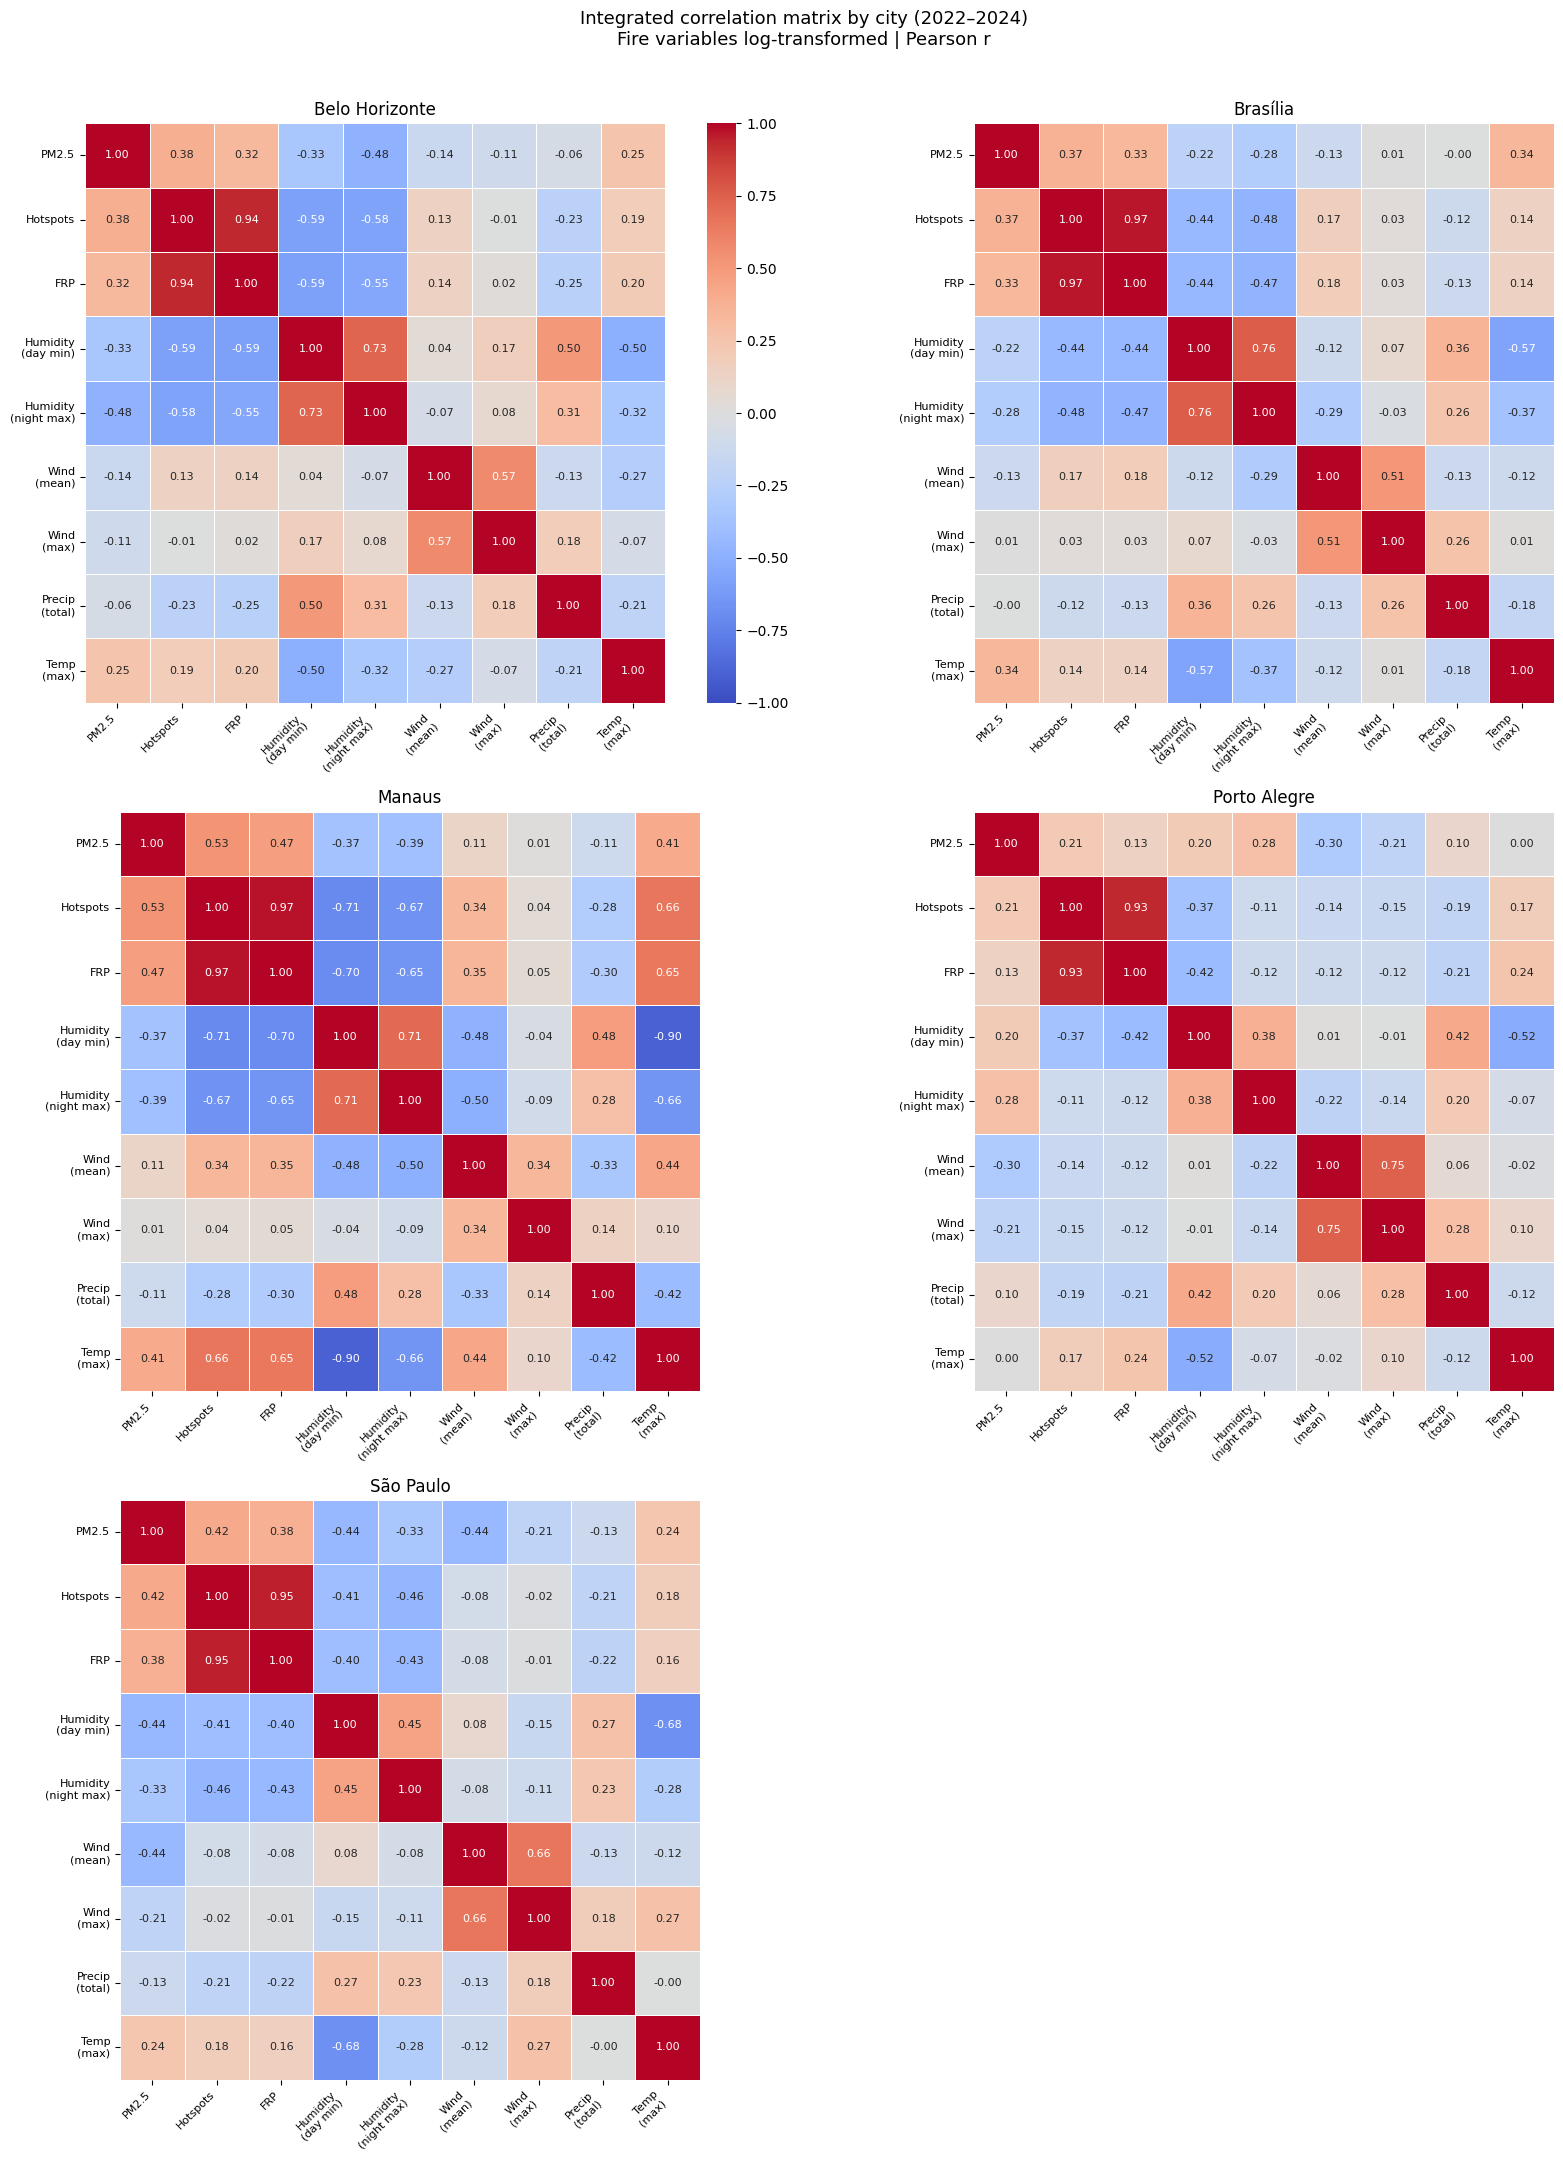

In [18]:
# ── Correlation heatmap — integrated variables per city ───────────────────────
# Shows pairwise Pearson correlations between key weather, fire, and air quality variables
# One heatmap per city — reveals which variables are most strongly related to PM2.5
# and how those relationships differ across climate regimes

import numpy as np

# Variables to include — focused set covering fire, weather, and air quality
corr_cols = {
    "pm25_ugm3":        "PM2.5",
    "hotspot_count":    "Hotspots",
    "frp_total":        "FRP",
    "humidity_min":     "Humidity\n(day min)",
    "humidity_max_night": "Humidity\n(night max)",
    "wind_mean":        "Wind\n(mean)",
    "wind_max":         "Wind\n(max)",
    "precip_total":     "Precip\n(total)",
    "temp_max":         "Temp\n(max)",
}

cities = sorted(df_integrated["city"].unique())
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 22))

for i, city in enumerate(cities):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    group = df_integrated[df_integrated["city"] == city][list(corr_cols.keys())].copy()

    # Log-transform fire variables before correlation
    # Reduces skewness and produces more meaningful linear correlations
    group["hotspot_count"] = np.log1p(group["hotspot_count"])  # log1p handles zeros
    group["frp_total"] = np.log1p(group["frp_total"])

    # Rename columns for cleaner labels
    group.columns = list(corr_cols.values())

    corr_matrix = group.corr(method="pearson")

    sns.heatmap(
        corr_matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar=i == 0,     # only show colorbar on first subplot
        annot_kws={"size": 8},
    )

    ax.set_title(city, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Integrated correlation matrix by city (2022–2024)\n"
    "Fire variables log-transformed | Pearson r",
    fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 5 — Integrated correlation matrix reveals city-specific dominant drivers

**Strongest PM2.5 predictor per city:**
- BH: nighttime humidity (-0.48) — temperature inversion trapping dominates;
  wind is not a significant PM2.5 predictor despite being consistently strong
- Brasília: temperature (0.34) marginally ahead of hotspots (0.37) —
  heat and fire activity are tightly coupled in the cerrado
- Manaus: hotspots (0.53) — fire smoke dominant; temperature predicts fires
  (r=0.66) which predict PM2.5 — an indirect chain rather than direct effect
- Porto Alegre: no predictor above 0.30 — none of these variables explain
  PM2.5 variation in a frontally-driven climate
- SP: daytime humidity (-0.44) and wind mean (-0.44) tied — urban ventilation
  and afternoon drought conditions equally important

**Universal findings:**
- Hotspots and FRP are redundant (r = 0.93–0.97) — use only one in modeling
- Day and night humidity correlated but carry different information per city

**City-specific inter-variable relationships:**
- Manaus temperature-humidity: r = -0.90 — strongest coupling in dataset,
  confirms Amazonian feedback loop from notebook 03
- SP temperature-humidity: r = -0.68 — second strongest coupling
- Brasília temperature-humidity: r = -0.57

**Modeling feature selection implications:**
- Drop FRP — redundant with log(hotspot_count)
- BH: use nighttime humidity, drop wind
- SP: use daytime humidity and wind mean
- Manaus: use hotspot count; temperature adds indirect predictive value
- Brasília: use both temperature and hotspot count
- Porto Alegre: current features insufficient — would need frontal
  weather variables not available in this dataset

# Integration EDA Summary

## What the combined data tells us

**Three distinct air quality regimes confirmed:**

1. **Fire-dominated cities (Manaus, Brasília)**
   - PM2.5 driven primarily by fire activity
   - Hotspot count is the strongest predictor
   - Temperature predicts fires which predict PM2.5 — indirect chain
   - Humidity collapses before and during fire peaks

2. **Urban-dominated city (São Paulo)**
   - Chronic PM2.5 elevation independent of fire season
   - Daytime humidity and wind equally important predictors
   - Fire amplifies an already elevated baseline in 2024
   - Temperature-humidity coupling strong (-0.68)

3. **Inversion-dominated city (Belo Horizonte)**
   - Nighttime humidity strongest PM2.5 predictor (-0.48)
   - Wind does not predict PM2.5 despite being consistently high
   - Fire signal present but secondary to atmospheric trapping

4. **Unexplained city (Porto Alegre)**
   - No variable in this dataset explains PM2.5 variation above r=0.30
   - Frontally-driven climate requires different predictors entirely
   - Recommend excluding from unified model or treating separately

## Key modeling decisions from EDA

- **Target variable:** PM2.5 (log-transformed recommended given skewness)
- **Drop:** FRP — redundant with hotspot count (r=0.93–0.97)
- **Log-transform:** hotspot count before modeling
- **City-specific features:**
  - BH: nighttime humidity
  - SP: daytime humidity + wind mean
  - Manaus/Brasília: hotspot count + temperature
- **Interaction term:** wind × hotspot_count — captures transport vs dispersion
- **Porto Alegre:** separate model or exclusion from unified model
- **2024 flag:** consider adding a binary 2024 indicator variable to capture
  the El Niño anomaly that affected all cities simultaneously

## Limitations

- Wind direction unavailable — cannot distinguish smoke transport from dispersion
- Fire data at state level — distant fires dilute the signal especially for Manaus
- SISAM reanalysis data — relative patterns more reliable than absolute values
- Porto Alegre PM2.5 drivers not captured in current feature set
- 3-year dataset — 2024 anomaly may dominate model training